In [1]:
import pandas as pd
import sqlite3
from sklearn.preprocessing import LabelEncoder

conexion = sqlite3.connect('../data/boca_juniors.db')
df = pd.read_sql_query("SELECT * FROM adn_boca", conexion)
conexion.close()

print(f"Dataset: {df.shape}")
print(df.isnull().sum())  # Verificamos nulos

Dataset: (386, 17)
nombre               0
temporada            0
posicion             0
edad                 0
partidos             0
goles                0
asistencias          0
pases_precisos       0
rating               0
etiqueta             0
goles_por_partido    0
asist_por_partido    0
rendimiento          0
participacion_gol    0
experiencia          0
pases_norm           0
perfil_ofensivo      0
dtype: int64


In [2]:
# Convertimos posición (texto) a número para el modelo
le = LabelEncoder()
df['posicion_encoded'] = le.fit_transform(df['posicion'])

# Features que usa el modelo para aprender
features = ['posicion_encoded', 'edad', 'partidos', 
            'goles', 'asistencias', 'pases_precisos', 'rating']

X = df[features]
y = df['etiqueta']

print("Distribución de etiquetas:")
print(y.value_counts())
print(f"\nFeatures: {features}")

Distribución de etiquetas:
etiqueta
1    222
0    164
Name: count, dtype: int64

Features: ['posicion_encoded', 'edad', 'partidos', 'goles', 'asistencias', 'pases_precisos', 'rating']


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest es ideal acá: robusto, no necesita muchos datos, 
# y te dice qué features importan más
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Evaluamos
y_pred = modelo.predict(X_test)
print("📊 Resultados del modelo:")
print(classification_report(y_test, y_pred, 
      target_names=['No encaja', 'Perfil Boca']))

# Guardamos el modelo para usarlo después en el dashboard
joblib.dump(modelo, '../models/modelo_adn_boca.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
print("\n✅ Modelo guardado en /models/")

📊 Resultados del modelo:
              precision    recall  f1-score   support

   No encaja       1.00      1.00      1.00        33
 Perfil Boca       1.00      1.00      1.00        45

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78


✅ Modelo guardado en /models/


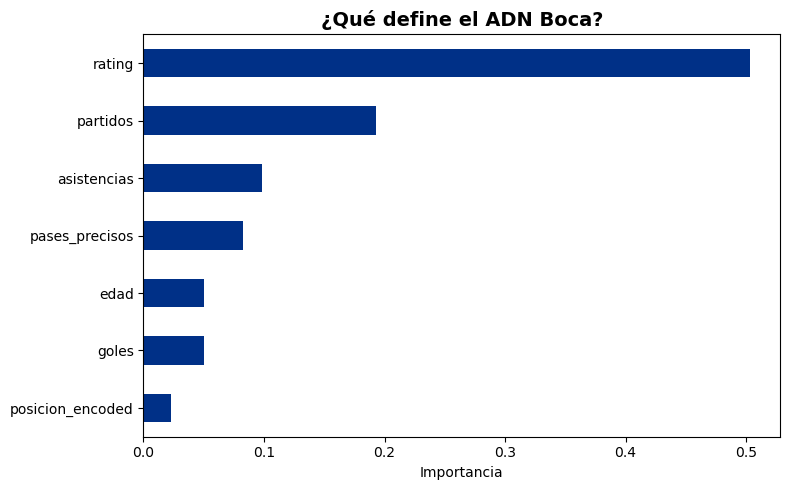

✅ Gráfico guardado


In [4]:
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo.feature_importances_, 
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='#003087')  # Azul Boca
ax.set_title('¿Qué define el ADN Boca?', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('../outputs/importancia_features.png', dpi=150)
plt.show()
print("✅ Gráfico guardado")

In [5]:

conexion = sqlite3.connect('../data/boca_juniors.db')
df_plantilla = pd.read_sql_query("SELECT * FROM plantilla", conexion)
conexion.close()

# Encoding de posición
df_plantilla['posicion_encoded'] = df_plantilla['posicion'].apply(
    lambda x: le.transform([x])[0] if x in le.classes_ else 0
)

X_plantilla = df_plantilla[features]

# Predicción
df_plantilla['encaja_boca'] = modelo.predict(X_plantilla)
df_plantilla['probabilidad'] = modelo.predict_proba(X_plantilla)[:, 1]

resultado = df_plantilla[['nombre', 'posicion', 'partidos', 'goles', 
                           'rating', 'probabilidad', 'encaja_boca']]
resultado = resultado.sort_values('probabilidad', ascending=False)

print("🏆 Top 10 jugadores con perfil Boca:")
print(resultado.head(10).to_string(index=False))

# ✅ Abrimos la conexión NUEVA justo antes de guardar
conexion2 = sqlite3.connect('../data/boca_juniors.db')
resultado.to_sql('scouting_resultado', conexion2, 
                 if_exists='replace', index=False)
conexion2.close()
print("\n✅ Resultados guardados en tabla 'scouting_resultado'")

ValueError: Found array with 0 sample(s) (shape=(0, 7)) while a minimum of 1 is required by RandomForestClassifier.